In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Generalizable-DDA-RL

import os

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Current directory:", os.getcwd())

/content/drive/MyDrive/Generalizable-DDA-RL
Current directory: /content/drive/MyDrive/Generalizable-DDA-RL


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Imports successful!")

Imports successful!


### ***Load Results***

In [4]:
results_df = pd.read_csv(
    "results/evaluation_raw_results.csv"
)

comparison_df = pd.read_csv(
    "results/ppo_vs_baselines.csv"
)

test_df = pd.read_csv(
    "results/statistical_tests.csv"
)

effect_df = pd.read_csv(
    "results/effect_sizes.csv"
)

print("Results Loaded")

print("\nEvaluation shape:", results_df.shape)

results_df.head()

Results Loaded

Evaluation shape: (200, 14)


,Player Profile,Method,Seed,Win Rate Error,Difficulty Change Std,Mean Absolute Difficulty Change,Episode Length,Total Reward,Mean Reward,Mean Win Rate,Final Win Rate,Mean Difficulty,Final Difficulty,Mean Error Rate
0,Stable,Static Easy,0,0.178294,0.005541,0.001206,200,143.087161,0.715436,0.865627,1.0,0.206,0.2,0.000053
1,Stable,Static Easy,1,0.219710,0.005541,0.001206,200,110.760788,0.553804,0.898710,0.9,0.206,0.2,0.000000
2,Stable,Static Easy,2,0.198000,0.005541,0.001206,200,129.389630,0.646948,0.898000,0.9,0.206,0.2,0.000000
3,Stable,Static Easy,3,0.211319,0.005541,0.001206,200,120.738169,0.603691,0.910319,0.9,0.206,0.2,0.000154
4,Stable,Static Easy,4,0.209444,0.005541,0.001206,200,121.203887,0.606019,0.901444,0.9,0.206,0.2,0.000190


### ***Define Method Order***
We want the figures to always use the same method order

In [5]:
method_order = [
    "Static Easy",
    "Static Medium",
    "Static Hard",
    "Rule-Based DDA",
    "PPO DDA"
]

TARGET_WIN_RATE = 0.70

print("Method Order Ready :)")

Method Order Ready :)


### ***Main Result : Win Rate Error***

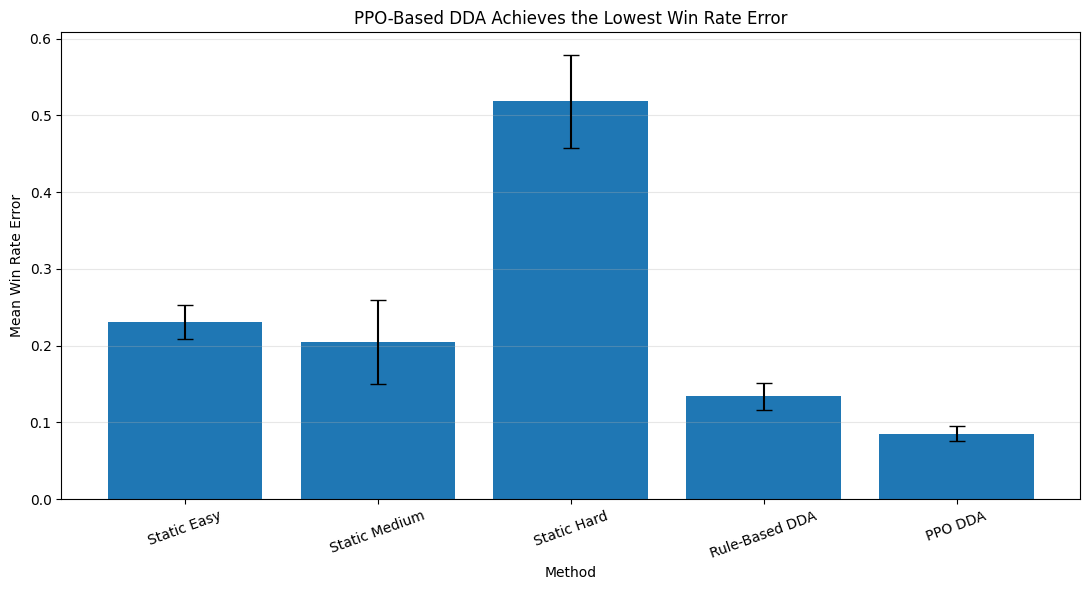

In [6]:
error_stats = (
    results_df
    .groupby("Method")["Win Rate Error"]
    .agg(["mean", "std"])
    .reindex(method_order)
)

plt.figure(figsize=(11, 6))

plt.bar(
    error_stats.index,
    error_stats["mean"],
    yerr=error_stats["std"],
    capsize=6
)

plt.xlabel("Method")
plt.ylabel("Mean Win Rate Error")

plt.title(
    "PPO-Based DDA Achieves the Lowest Win Rate Error"
)

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/Figure_1_Main_Performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***PPO vs Rule Based DDA***

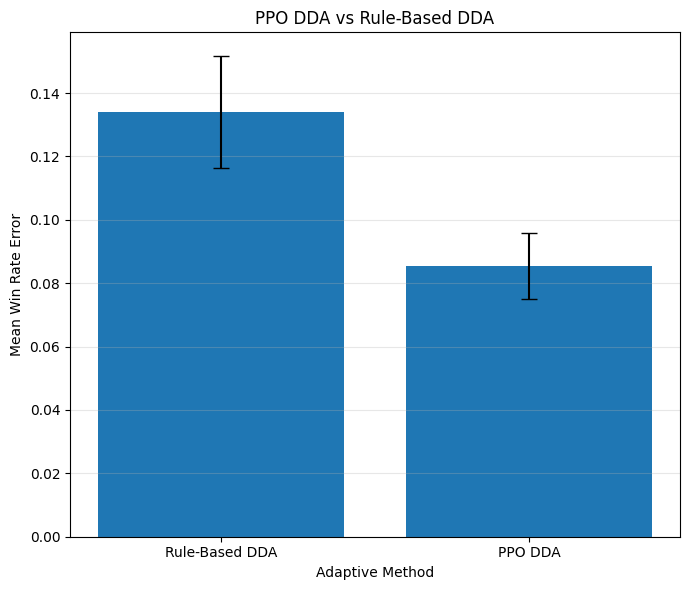

In [7]:
adaptive_methods = [
    "Rule-Based DDA",
    "PPO DDA"
]

adaptive_stats = (
    results_df[
        results_df["Method"].isin(adaptive_methods)
    ]
    .groupby("Method")["Win Rate Error"]
    .agg(["mean", "std"])
    .reindex(adaptive_methods)
)

plt.figure(figsize=(7, 6))

plt.bar(
    adaptive_stats.index,
    adaptive_stats["mean"],
    yerr=adaptive_stats["std"],
    capsize=6
)

plt.xlabel("Adaptive Method")
plt.ylabel("Mean Win Rate Error")

plt.title(
    "PPO DDA vs Rule-Based DDA"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/Figure_2_PPO_vs_Rule_Based.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Performance across Profiles***
This demonstrates generalization across non-stationary players

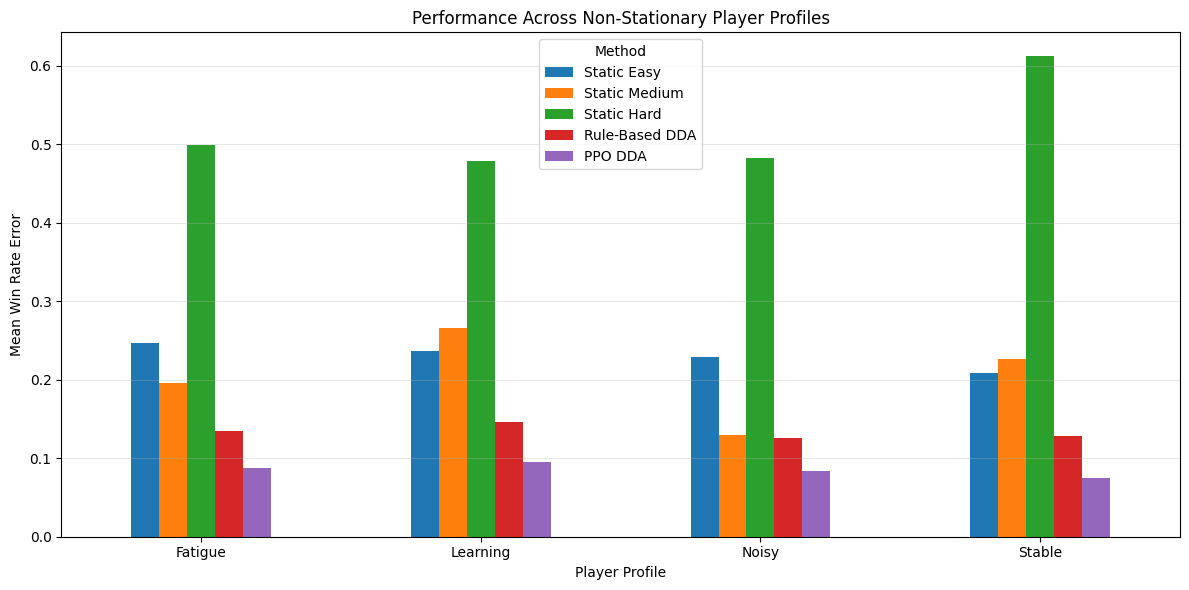

In [8]:
profile_method_stats = (
    results_df
    .groupby(
        ["Player Profile", "Method"]
    )["Win Rate Error"]
    .mean()
    .unstack()
)

profile_method_stats = (
    profile_method_stats[
        method_order
    ]
)

ax = profile_method_stats.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_xlabel("Player Profile")
ax.set_ylabel("Mean Win Rate Error")

ax.set_title(
    "Performance Across Non-Stationary Player Profiles"
)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend(
    title="Method"
)

plt.tight_layout()

plt.savefig(
    "figures/Figure_3_Profile_Robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Accuracy vs Smoothness Trade-Off***
Lower Win Rate Error is better

Lower Difficulty Change Std means smoother adaptation

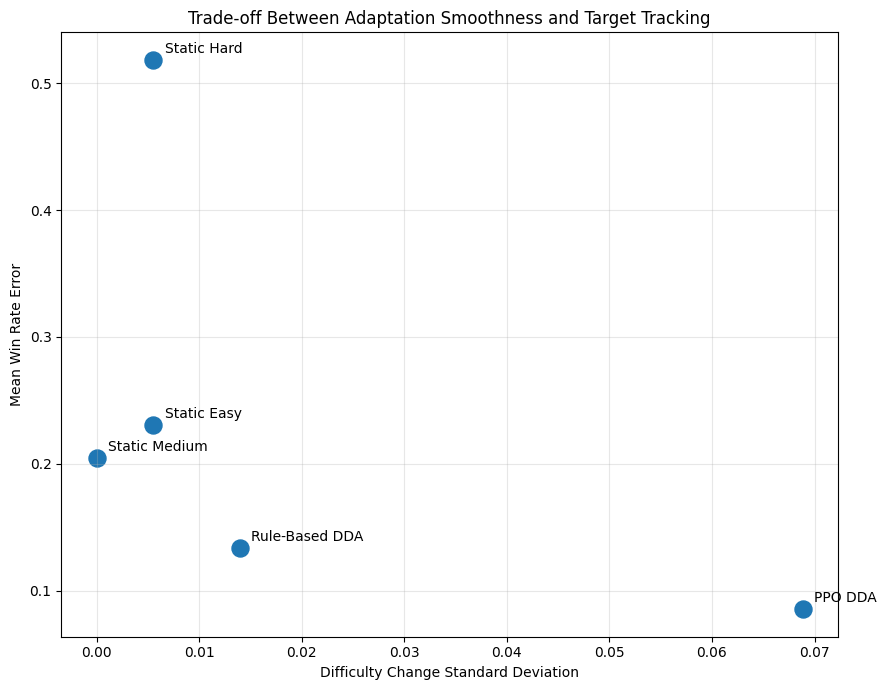

In [9]:
tradeoff_stats = (
    results_df
    .groupby("Method")
    .agg(
        Win_Rate_Error=(
            "Win Rate Error",
            "mean"
        ),
        Difficulty_Smoothness=(
            "Difficulty Change Std",
            "mean"
        )
    )
    .reindex(method_order)
)

plt.figure(figsize=(9, 7))

plt.scatter(
    tradeoff_stats["Difficulty_Smoothness"],
    tradeoff_stats["Win_Rate_Error"],
    s=150
)

for method in tradeoff_stats.index:

    plt.annotate(
        method,
        (
            tradeoff_stats.loc[
                method,
                "Difficulty_Smoothness"
            ],
            tradeoff_stats.loc[
                method,
                "Win_Rate_Error"
            ]
        ),
        xytext=(8, 5),
        textcoords="offset points"
    )

plt.xlabel(
    "Difficulty Change Standard Deviation"
)

plt.ylabel(
    "Mean Win Rate Error"
)

plt.title(
    "Trade-off Between Adaptation Smoothness and Target Tracking"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figures/Figure_4_Accuracy_vs_Smoothness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Total Reward***

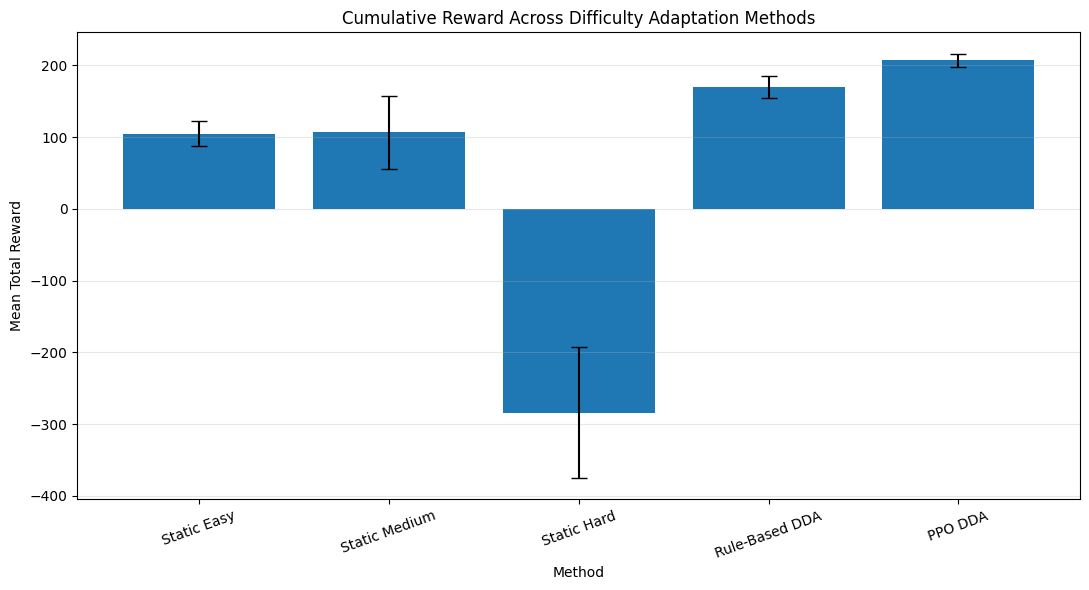

In [10]:
reward_stats = (
    results_df
    .groupby("Method")["Total Reward"]
    .agg(["mean", "std"])
    .reindex(method_order)
)

plt.figure(figsize=(11, 6))

plt.bar(
    reward_stats.index,
    reward_stats["mean"],
    yerr=reward_stats["std"],
    capsize=6
)

plt.xlabel("Method")
plt.ylabel("Mean Total Reward")

plt.title(
    "Cumulative Reward Across Difficulty Adaptation Methods"
)

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/Figure_5_Total_Reward.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Mean Win Rate vs Target***
This helps readers understand why PPO performs well

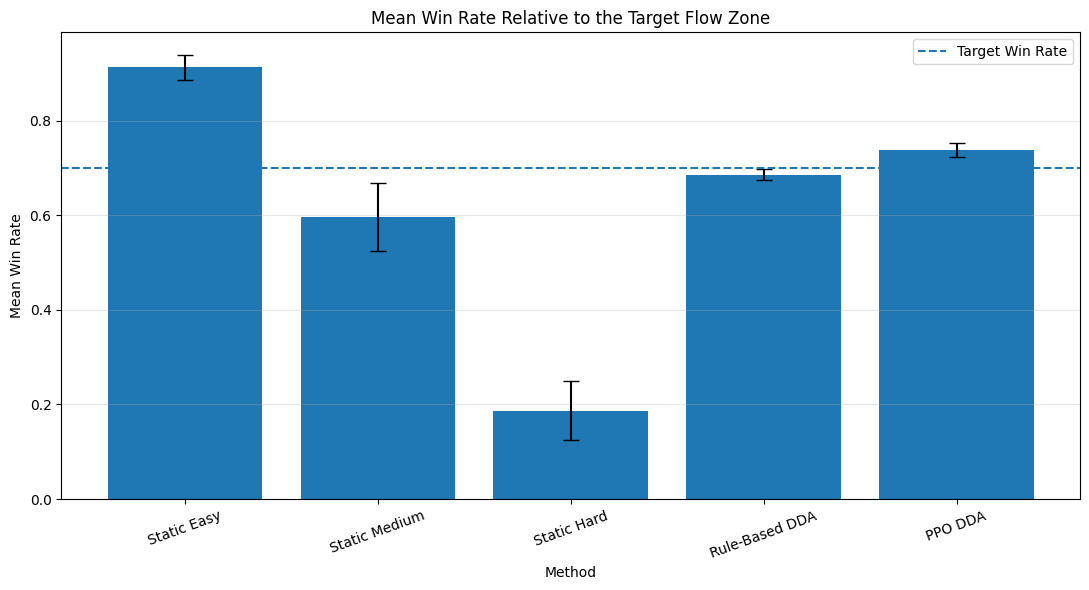

In [11]:
win_rate_stats = (
    results_df
    .groupby("Method")["Mean Win Rate"]
    .agg(["mean", "std"])
    .reindex(method_order)
)

plt.figure(figsize=(11, 6))

plt.bar(
    win_rate_stats.index,
    win_rate_stats["mean"],
    yerr=win_rate_stats["std"],
    capsize=6
)

plt.axhline(
    TARGET_WIN_RATE,
    linestyle="--",
    label="Target Win Rate"
)

plt.xlabel("Method")
plt.ylabel("Mean Win Rate")

plt.title(
    "Mean Win Rate Relative to the Target Flow Zone"
)

plt.xticks(rotation=20)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/Figure_6_Mean_Win_Rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Main Results***
Publication Ready

In [12]:
table_metrics = [
    "Win Rate Error",
    "Difficulty Change Std",
    "Total Reward",
    "Mean Win Rate"
]

table_data = []

for method in method_order:

    method_data = results_df[
        results_df["Method"] == method
    ]

    row = {
        "Method": method
    }

    for metric in table_metrics:

        mean_value = (
            method_data[metric]
            .mean()
        )

        std_value = (
            method_data[metric]
            .std()
        )

        row[metric] = (
            f"{mean_value:.4f} ± "
            f"{std_value:.4f}"
        )

    table_data.append(row)

paper_table = pd.DataFrame(
    table_data
)

paper_table

,Method,Win Rate Error,Difficulty Change Std,Total Reward,Mean Win Rate
0,Static Easy,0.2303 ± 0.0222,0.0055 ± 0.0000,104.8669 ± 17.0669,0.9122 ± 0.0272
1,Static Medium,0.2045 ± 0.0545,0.0000 ± 0.0000,106.6023 ± 50.6272,0.5964 ± 0.0726
2,Static Hard,0.5183 ± 0.0611,0.0055 ± 0.0000,-283.8857 ± 91.1188,0.1864 ± 0.0624
3,Rule-Based DDA,0.1340 ± 0.0176,0.0140 ± 0.0005,169.7896 ± 15.2826,0.6857 ± 0.0121
4,PPO DDA,0.0855 ± 0.0103,0.0688 ± 0.0024,207.3371 ± 9.1353,0.7374 ± 0.0142


In [13]:
paper_table.to_csv(
    "results/Table_1_Main_Results.csv",
    index=False
)

print("Table 1 saved successfully!")

Table 1 saved successfully!


### ***PPO vs Baselines***

In [14]:
comparison_display = comparison_df.copy()

comparison_display["Comparison"] = (
    "PPO DDA vs "
    +
    comparison_display["Baseline"]
)

table_ppo = comparison_display.merge(
    effect_df,
    on="Comparison",
    how="left"
)

table_ppo

,Baseline,PPO Win Rate Error,Baseline Win Rate Error,PPO Improvement (%),Comparison,Cohen's d
0,Static Easy,0.0855,0.2303,62.8808,PPO DDA vs Static Easy,9.5783
1,Static Medium,0.0855,0.2045,58.2047,PPO DDA vs Static Medium,7.5446
2,Static Hard,0.0855,0.5183,83.5076,PPO DDA vs Static Hard,21.4925
3,Rule-Based DDA,0.0855,0.1340,36.1912,PPO DDA vs Rule-Based DDA,4.2157


In [15]:
table_ppo.to_csv(
    "results/Table_2_PPO_vs_Baselines.csv",
    index=False
)

print("Table 2 saved successfully!")

Table 2 saved successfully!


## ***Statistical Evidence***

In [18]:
statistical_table = test_df.merge(
    effect_df,
    on="Comparison",
    how="left"
)

statistical_table

,Comparison,Test,Statistic,P-value,Significant (p < 0.05),Cohen's d
0,PPO DDA vs Static Easy,Paired t-test,-30.289129,0.0,True,9.5783
1,PPO DDA vs Static Medium,Paired t-test,-23.858106,0.0,True,7.5446
2,PPO DDA vs Static Hard,Paired t-test,-67.965106,0.0,True,21.4925
3,PPO DDA vs Rule-Based DDA,Paired t-test,-13.331080,0.0,True,4.2157


In [19]:
statistical_table.to_csv(
    "results/Table_3_Statistical_Results.csv",
    index=False
)

print("Table 3 saved successfully!")

Table 3 saved successfully!


### ***Final Results Summary***

In [20]:
ppo_row = results_df[
    results_df["Method"] == "PPO DDA"
]

rule_row = results_df[
    results_df["Method"] == "Rule-Based DDA"
]

ppo_error = ppo_row[
    "Win Rate Error"
].mean()

rule_error = rule_row[
    "Win Rate Error"
].mean()

improvement = (
    (
        rule_error
        -
        ppo_error
    )
    /
    rule_error
    *
    100
)

ppo_reward = ppo_row[
    "Total Reward"
].mean()

rule_reward = rule_row[
    "Total Reward"
].mean()

print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

print(
    f"\nPPO Win Rate Error: "
    f"{ppo_error:.4f}"
)

print(
    f"Rule-Based Win Rate Error: "
    f"{rule_error:.4f}"
)

print(
    f"\nPPO Improvement over Rule-Based DDA: "
    f"{improvement:.2f}%"
)

print(
    f"\nPPO Mean Total Reward: "
    f"{ppo_reward:.2f}"
)

print(
    f"Rule-Based Mean Total Reward: "
    f"{rule_reward:.2f}"
)

print("\nKey conclusion:")

print(
    "Within the evaluated simulated player "
    "profiles, PPO DDA achieved better target "
    "tracking than the rule-based DDA baseline."
)

FINAL RESULTS SUMMARY

PPO Win Rate Error: 0.0855
Rule-Based Win Rate Error: 0.1340

PPO Improvement over Rule-Based DDA: 36.19%

PPO Mean Total Reward: 207.34
Rule-Based Mean Total Reward: 169.79

Key conclusion:
Within the evaluated simulated player profiles, PPO DDA achieved better target tracking than the rule-based DDA baseline.


In [21]:
print("FINAL RESULTS FILES")
print("=" * 50)

!ls -lh results/

print("\nFINAL FIGURES")
print("=" * 50)

!ls -lh figures/

FINAL RESULTS FILES
total 66K
-rw------- 1 root root  147 Sep  9 17:23 effect_sizes.csv
-rw------- 1 root root  38K Sep  8 18:37 evaluation_raw_results.csv
-rw------- 1 root root 3.2K Sep  8 18:39 evaluation_summary.csv
drwx------ 2 root root 4.0K Sep  7 14:26 figures
-rw------- 1 root root  298 Sep  9 17:27 final_method_ranking.csv
-rw------- 1 root root  766 Sep  9 17:07 mean_std_results.csv
-rw------- 1 root root  868 Sep  9 17:05 overall_statistics.csv
-rw------- 1 root root  212 Sep  9 17:11 ppo_vs_baselines.csv
-rw------- 1 root root 2.6K Sep  9 17:09 profile_statistics.csv
-rw------- 1 root root  289 Sep  9 17:21 statistical_tests.csv
-rw------- 1 root root  487 Sep 10 15:38 Table_1_Main_Results.csv
-rw------- 1 root root  359 Sep 10 15:39 Table_2_PPO_vs_Baselines.csv
-rw------- 1 root root  328 Sep 10 15:41 Table_3_Statistical_Results.csv
drwx------ 2 root root 4.0K Sep  7 14:26 tables
drwx------ 2 root root 4.0K Sep  8 09:15 training
drwx------ 2 root root 4.0K Sep  7 14:26 tr